In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

import c2qa
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RGate
from qiskit.converters import circuit_to_gate
from qutip import *
from qiskit.circuit import Parameter
from qiskit.circuit.library import UnitaryGate
from custom_gates import state_generation
from qiskit.visualization import plot_histogram

In [ ]:
Nmodes=1 
Nqubits = 1 
cutoff = 2**7 
delta = 0.222
N_rounds = 9
alpha = np.sqrt(np.pi) 

a = destroy(cutoff)
x = position(cutoff)
p = momentum(cutoff)

r = -np.log(delta) 

qmr = c2qa.QumodeRegister(num_qumodes=1, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))))

qbr = QuantumRegister(Nqubits)
cbr = ClassicalRegister(Nqubits)

circuit = c2qa.CVCircuit(qmr, qbr,cbr)
circuit.cv_sq(r,qmr[0])

for k in range(1,N_rounds):
    circuit.cv_c_d(alpha,qmr[0],qbr[0])
    Uxk = state_generation.Ux_operator(cutoff,alpha,4*k,delta)
    Ux_gate = UnitaryGate(Uxk.full(), label=f'Ux_{k}')
    circuit.append(Ux_gate, qmr[:] + qbr[:])
    
stateop, result, _ = c2qa.util.simulate(circuit,shots = 1024)

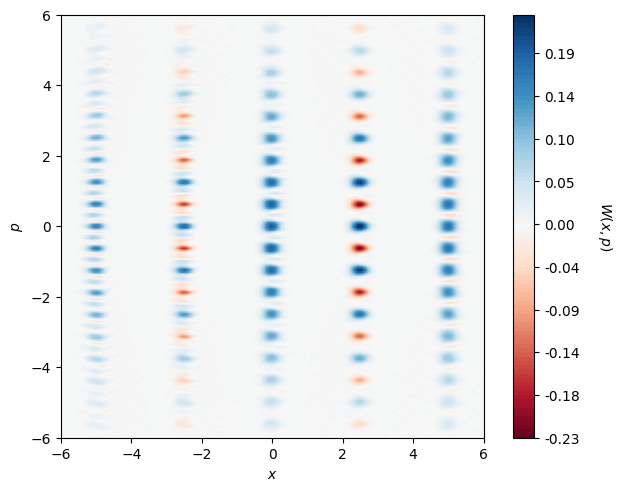

In [39]:
fig = c2qa.wigner.plot_wigner(circuit, stateop)